# Import Dependencies

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

In [2]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split

from src.features import add_band_availability, add_cation_ratio, add_missing_indicators
from src.modeling.evaluate import get_oof_predictions

# Load Data & Reproduksi Feature Set

In [3]:
# Load dataset
df = pd.read_csv("../data/raw/train.csv", index_col="sample_id")
df.head()

,source_id,has_band_A_spectrum,has_band_B_spectrum,sampling_strategy,sampling_depth_cm,geo_zone_macro,geo_zone_micro,geo_zone_meso,land_cover_type,biome,...,spectral_band_B_PC_6,spectral_band_B_PC_7,spectral_band_B_PC_8,spectral_band_B_PC_9,spectral_band_B_PC_10,spectral_band_B_PC_11,spectral_band_B_PC_12,spectral_band_B_PC_13,spectral_band_B_PC_14,spectral_band_B_PC_15
sample_id,,,,,,,,,,,,,,,,,,,,,
train_00001,Source_01,YES,NO,Auger,0-20,SE,Unknown,State_01,Seasonal Semideciduous Forest,Mata Atlantica,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00002,Source_10,YES,NO,Auger,0-20,MW,Loc_011,State_10,Savannah,Cerrado,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00003,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00004,Source_02,YES,NO,Auger,0-20,N,Unknown,State_07,Unknown,Amazonia,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
train_00005,Source_04,YES,NO,Auger,0-20,S,Loc_001,State_06,Unknown,Unknown,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Pembuatan fitur-fitur tambahan
df = add_missing_indicators(df)
df = add_band_availability(df)
df = add_cation_ratio(df)

In [5]:
# Split dataset
X = df.drop(columns="property_organic_content")
y = df["property_organic_content"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=X["source_id"], random_state=42)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((8968, 59), (2242, 59), (8968,), (2242,))

In [6]:
# Categorical fetures
cat_feats = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

# Load Study & Rekonstruksi Best Params

In [7]:
study = joblib.load("../outputs/study.pkl")

best_params = {"eval_metric": "RMSE", **study.best_params}

c:\Users\ASUS\miniconda3\envs\compfest_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Out-of-Fold Predictions

In [8]:
# Splitter sama persis dengan yang dipakai tuning
skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

oof_preds = get_oof_predictions(
    X=X_train,
    y=y_train,
    cat_features=cat_feats,
    splitter=skf,
    params=best_params,
)

residuals = y_train - oof_preds

print(f"OOF RMSE : {((residuals**2).mean()) ** 0.5:.6f}")
print(f"Residual mean : {residuals.mean():.6f}")
print(f"Residual std  : {residuals.std():.6f}")

OOF RMSE : 12.158766
Residual mean : 0.118810
Residual std  : 12.158864


## Distribusi & Pola Residual

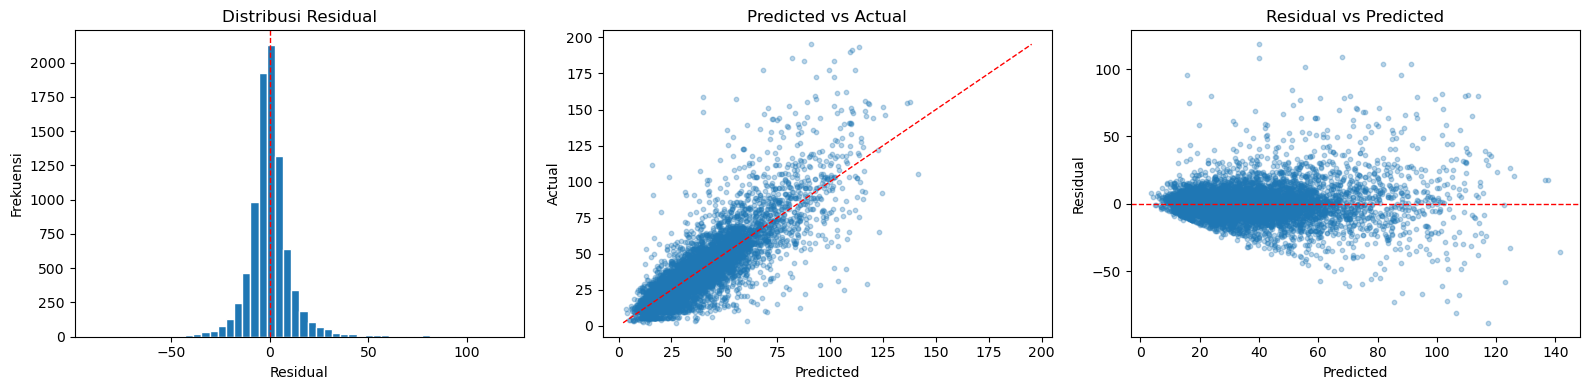

In [9]:
oof_df = pd.DataFrame(
    {
        "actual": y_train,
        "predicted": oof_preds,
        "residual": residuals,
        "abs_residual": residuals.abs(),
    }
).join(
    X_train[
        ["source_id", "sampling_strategy"]
        + [c for c in X_train.columns if c.startswith("missing_")]
    ]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram residual
axes[0].hist(oof_df["residual"], bins=50, edgecolor="white")
axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribusi Residual")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frekuensi")

# Predicted vs Actual
axes[1].scatter(oof_df["predicted"], oof_df["actual"], alpha=0.3, s=10)
lims = [
    min(oof_df["predicted"].min(), oof_df["actual"].min()),
    max(oof_df["predicted"].max(), oof_df["actual"].max()),
]
axes[1].plot(lims, lims, "r--", linewidth=1)
axes[1].set_title("Predicted vs Actual")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# Residual vs Predicted
axes[2].scatter(oof_df["predicted"], oof_df["residual"], alpha=0.3, s=10)
axes[2].axhline(0, color="red", linestyle="--", linewidth=1)
axes[2].set_title("Residual vs Predicted")
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()

* **`Predicted vs Actual`** menunjukkan heteroskedastisitas<br>
titik rapat di sekitar diagonal pada rentang rendah (0-50), tapi melebar signifikan di rentang tinggi (>100). Di nilai actual tinggi (>125), beberapa titik jauh di atas garis, yang mana artinya model under-predict pada kasus-kasus besar.
* **`Residual vs Predicted`** mengonfirmasi pola corong<br>
residual rapat di sekitar 0 saat predicted rendah, melebar jauh (sampai +100) saat predicted naik ke 40-80. Sebaran juga condong positif di rentang menengah, menandakan bias under-prediction yang konsisten dengan panel sebelumnya.

## Error per Segmen

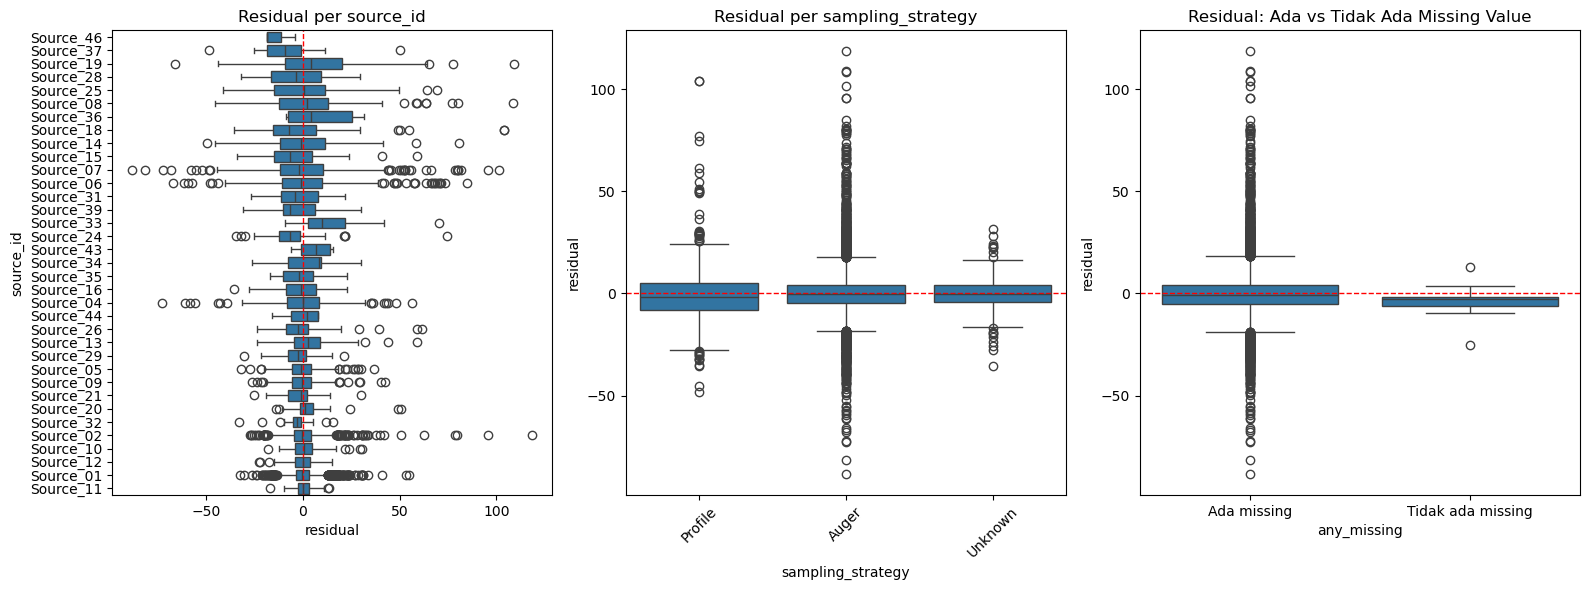

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Per source_id
source_order = (
    oof_df.groupby("source_id")["abs_residual"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(data=oof_df, y="source_id", x="residual", order=source_order, ax=axes[0])

axes[0].axvline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residual per source_id")

# Per sampling_strategy
strategy_order = (
    oof_df.groupby("sampling_strategy")["abs_residual"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=oof_df, x="sampling_strategy", y="residual", order=strategy_order, ax=axes[1]
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1)
axes[1].set_title("Residual per sampling_strategy")
axes[1].tick_params(axis="x", rotation=45)

# Per ada/tidaknya missing value (pakai fitur indikator)
missing_cols = [c for c in X_train.columns if c.endswith("missing")]
oof_df["any_missing"] = (
    X_train[missing_cols]
    .any(axis=1)
    .map({True: "Ada missing", False: "Tidak ada missing"})
)
sns.boxplot(data=oof_df, x="any_missing", y="residual", ax=axes[2])
axes[2].axhline(0, color="red", linestyle="--", linewidth=1)
axes[2].set_title("Residual: Ada vs Tidak Ada Missing Value")

plt.tight_layout()
plt.show()

* Residual per `source_id` menunjukkan keragaman yang cukup besar antar *source*. Sebagian besar `source_id` punya median residual dekat 0 dengan IQR yang relatif sempit (Source_46, Source_24, Source_02, Source_11 di ekor bawah), tapi beberapa `source_id` punya median yang condong jelas ke arah positif dengan box yang lebih lebar — Source_19, Source_28, Source_25, Source_08, Source_36, Source_18 di bagian atas urutan. Source-source ini diurutkan berdasarkan median *absolute residual* tertinggi, jadi urutan ini sendiri sudah menunjukkan source mana yang error-nya paling besar secara konsisten. Banyak *source* juga punya *outlier* ekstrem di kedua arah (titik-titik di luar *whisker* sampai ±100), tapi pola median yang condong positif pada *source*-*source* teratas ini sejalan dengan bias *under-prediction* yang sudah terlihat di plot sebelumnya — kemungkinan *source*-*source* ini punya proporsi nilai *actual* tinggi yang lebih besar, atau karakteristik lain yang membuat model sistematis meremehkan prediksinya.

* Residual per `sampling_strategy` menunjukkan pola yang lebih jelas. "Profile" punya sebaran residual paling lebar dengan *whisker* memanjang jauh ke kedua arah (sampai -50 dan +50 di luar *outlier*), dan IQR-nya sendiri sudah condong negatif (median sedikit di bawah 0, box bagian bawah lebih panjang). "Auger" punya IQR yang jauh lebih sempit dan rapat di sekitar 0, tapi punya jumlah *outlier* yang sangat banyak di sisi positif (titik-titik bertumpuk dari +20 sampai +120) — pola ini konsisten dengan bias *under-prediction* yang terkonsentrasi pada strategi ini meski mayoritas datanya diprediksi cukup baik. "Unknown" punya sebaran paling sempit dari ketiganya, dengan beberapa *outlier* tapi magnitude-nya lebih kecil dibanding dua strategi lain. 

> "Auger" tampak jadi kontributor utama untuk error-error besar berbentuk `under-prediction` (outlier positif jauh lebih banyak dan lebih ekstrem dibanding "Profile" atau "Unknown"), sementara "Profile" justru menunjukkan bias yang lebih merata ke kedua arah dengan sebaran keseluruhan yang lebih lebar.

* "Ada missing" punya sebaran jauh lebih lebar dengan ratusan *outlier* di kedua arah, mencerminkan bahwa mayoritas dataset memang masuk kategori ini sehingga otomatis mewarisi keragaman keseluruhan data. "Tidak ada missing" punya box yang jauh lebih sempit dan median sedikit di bawah 0, tapi karena jumlah datanya tampak sangat kecil (cuma 2 *outlier* terlihat, tidak ada tumpukan titik seperti grup sebelahnya), sulit menyimpulkan apakah grup ini benar-benar punya error lebih rendah secara sistematis, atau cuma kebetulan sampelnya sedikit dan belum mewakili variasi penuh.

## Kasus dengan Error Terbesar

In [11]:
N = 20

top_errors = (
    oof_df.nlargest(N, "abs_residual")
    [["actual", "predicted", "residual", "abs_residual", "source_id", "sampling_strategy", "any_missing"]]
    .round(4)
)

print(f"Top {N} kasus dengan absolute residual terbesar:\n")
display(top_errors)

print("\nDistribusi source_id di top errors:")
display(top_errors["source_id"].value_counts())

print("\nDistribusi sampling_strategy di top errors:")
display(top_errors["sampling_strategy"].value_counts())

print("\nDistribusi ada/tidaknya missing value di top errors:")
display(top_errors["any_missing"].value_counts())

Top 20 kasus dengan absolute residual terbesar:



,actual,predicted,residual,abs_residual,source_id,sampling_strategy,any_missing
sample_id,,,,,,,
train_10998,158.5669,40.0809,118.4860,118.4860,Source_02,Auger,Ada missing
train_04606,177.0610,68.1415,108.9196,108.9196,Source_19,Auger,Ada missing
train_03392,148.4273,39.8955,108.5317,108.5317,Source_08,Auger,Ada missing
train_06874,185.9440,81.7926,104.1515,104.1515,Source_18,Profile,Ada missing
train_03042,195.2315,91.1648,104.0667,104.0667,Source_18,Profile,Ada missing
train_06613,157.0460,55.4730,101.5730,101.5730,Source_07,Auger,Ada missing
train_05926,111.6441,15.7239,95.9202,95.9202,Source_02,Auger,Ada missing
train_07563,183.4037,87.8226,95.5811,95.5811,Source_07,Auger,Ada missing
train_04091,28.8592,117.2716,-88.4124,88.4124,Source_07,Auger,Ada missing



Distribusi source_id di top errors:


source_id
Source_07    9
Source_02    4
Source_08    2
Source_18    2
Source_19    1
Source_06    1
Source_14    1
Name: count, dtype: int64


Distribusi sampling_strategy di top errors:


sampling_strategy
Auger      18
Profile     2
Name: count, dtype: int64


Distribusi ada/tidaknya missing value di top errors:


any_missing
Ada missing    20
Name: count, dtype: int64

* `sampling_strategy = Auger` mendominasi top 20 dengan 18 dari 20 kasus (90%). Ini mengonfirmasi bahwa kasus-kasus dengan error absolut terbesar hampir seluruhnya berasal dari strategi sampling ini.

* `source_id = Source_07` sendirian menyumbang 9 dari 20 kasus (45%) — hampir setengah dari seluruh *top errors* berasal dari satu source ini saja. Ini jauh lebih terkonsentrasi dari yang terlihat di boxplot per-`source_id` sebelumnya, yang hanya menunjukkan Source_07 sebagai salah satu dari banyak *source* dengan IQR lebar berisi *outlier*. Kalau ditotal dengan Source_02 (4 kasus), dua *source* ini saja sudah menyumbang 13 dari 20 kasus *top error* (65%).

* `any_missing = "Ada missing"` untuk seluruh 20 kasus, 100%. Tapi ini perlu dibaca hati-hati mengingat temuan sebelumnya bahwa grup "Tidak ada missing" jumlah barisnya sangat kecil di keseluruhan dataset. Kalau proporsi "Ada missing" di seluruh data memang sudah mendekati 100% (misalnya 95%+), maka melihat semua top-20 error juga "Ada missing" tidak banyak menambah informasi — itu cuma refleksi dari base rate, bukan sinyal bahwa *missing value* secara spesifik menyebabkan error besar. 

* Arah error tidak seragam meski semua dari kategori "error besar" yang sama. Mayoritas kasus adalah *under-prediction* (actual jauh lebih tinggi dari predicted, residual positif besar — misalnya baris pertama actual 158.57 vs predicted 40.08), tapi ada juga dua kasus *over-prediction* ekstrem dari Source_07 sendiri (train_04091: actual 28.86 vs predicted 117.27, residual -88.41; train_01144: actual 25.13 vs predicted 106.51, residual -81.38). Artinya Source_07 bukan cuma *under-predict* secara konsisten — source ini punya rentang nilai actual yang sangat lebar (dari ~25 sampai ~190) dan model kesulitan menangkap pola di source ini ke kedua arah, bukan hanya bias satu arah. Ini pola yang berbeda dari *source*-*source* lain di tabel yang semuanya *under-prediction*.